In [70]:
import pandas as pd
#%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [71]:
#import dataset from UCI ML Repo
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
  
# metadata 
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [72]:
X.head(10)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
5,Caucasian,Male,[50-60),NaN,2,1,2,3,NaN,NaN,...,No,No,Steady,No,No,No,No,No,No,Yes
6,Caucasian,Male,[60-70),NaN,3,1,2,4,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
7,Caucasian,Male,[70-80),NaN,1,1,7,5,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
8,Caucasian,Female,[80-90),NaN,2,1,4,13,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
9,Caucasian,Female,[90-100),NaN,3,3,4,12,NaN,InternalMedicine,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [73]:
y['readmitted'].unique()

<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str

In [74]:
#convert to binary so I am only predicting >30 days readmission
y['readmitted'] = (y['readmitted'] == '>30').astype(int)

In [75]:
y.head(10)

,readmitted
0,0
1,1
2,0
3,0
4,0
5,1
6,0
7,1
8,0
9,0


In [76]:
X.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='str')

In [77]:
X.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Text(0.5, 0, 'Admission Type ID')

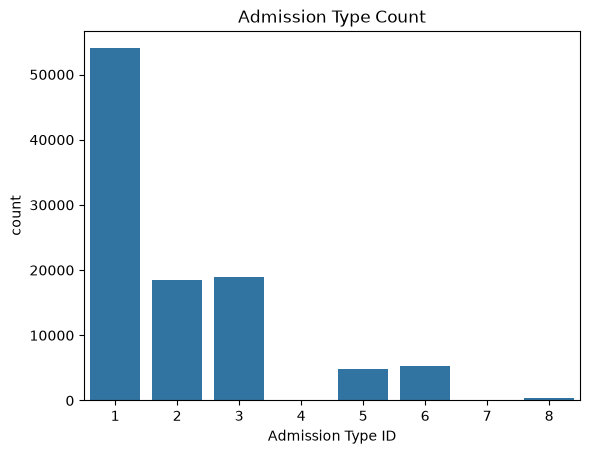

In [78]:
admission_type_col = X['admission_type_id'].value_counts()

sns.barplot(data=admission_type_col)
plt.title('Admission Type Count')
plt.xlabel('Admission Type ID')


Admission Type ID:
- 1 = Emergency
- 2 = Urgent
- 3 = Elective
- 4 = Newborn
- 5 = N/A
- 6 = NULL
- 7 = Trauma Center
- 8 =Not Mapped

Text(0.5, 0, 'Admission Source ID')

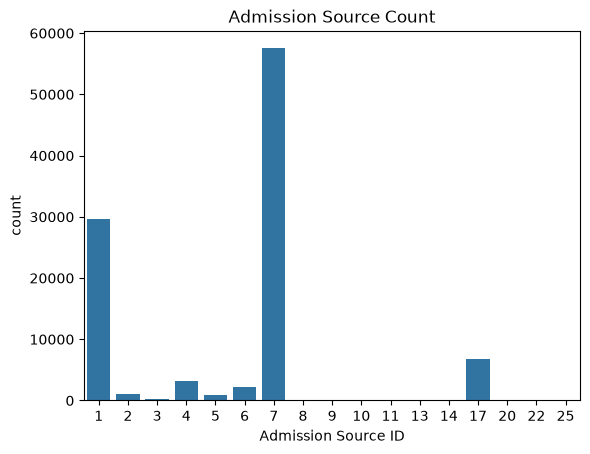

In [79]:
admission_source_col = X['admission_source_id'].value_counts()

sns.barplot(data=admission_source_col)
plt.title('Admission Source Count')
plt.xlabel('Admission Source ID')

Most Prominent Admission Source ID:
- 1 = Physician Referral
- 7 = Emergency Room
- 17 = Null 

Text(0.5, 1.0, 'Proportion of Patients on Diabetes')

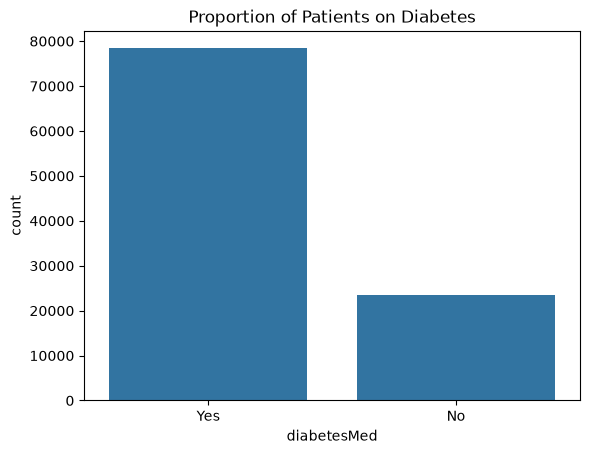

In [80]:
count_onMed = X['diabetesMed'].value_counts(ascending=False)

sns.barplot(data=count_onMed)
plt.title('Proportion of Patients on Diabetes')

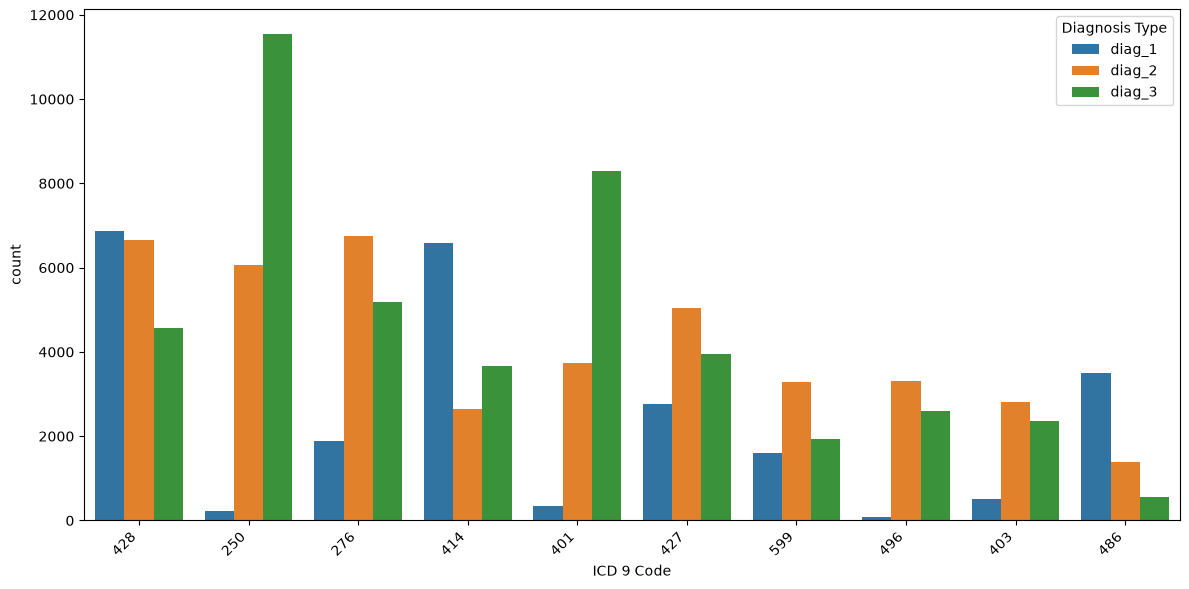

In [81]:
diag_long = pd.melt(
    X[['diag_1', 'diag_2', 'diag_3']],
    var_name='Diagnosis Type',
    value_name='ICD 9 Code'
)

plt.figure(figsize=(12, 6))
top_codes = diag_long['ICD 9 Code'].value_counts().head(10).index
sns.countplot(data=diag_long[diag_long['ICD 9 Code'].isin(top_codes)],
              x='ICD 9 Code', hue='Diagnosis Type',
              order=top_codes)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [82]:
X[['num_lab_procedures', 'num_procedures', 'num_medications']].describe()

,num_lab_procedures,num_procedures,num_medications
count,101766.000000,101766.000000,101766.000000
mean,43.095641,1.339730,16.021844
std,19.674362,1.705807,8.127566
min,1.000000,0.000000,1.000000
25%,31.000000,0.000000,10.000000
50%,44.000000,1.000000,15.000000
75%,57.000000,2.000000,20.000000
max,132.000000,6.000000,81.000000


In [83]:
# Percentage of missing values per feature
missing_pct = (X.isnull().sum() / len(X)) * 100

# Filter and display only features with missing values
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(missing_pct.to_string())

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636


In [84]:
#remove weight, max_glu_serum, A1Cresult, medical_specialty and payer code 
#because of the large amount of missing values
copyX_df = X.drop(columns=['weight','max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code'])
copyX_df.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,No,Steady,No,No,No,No,No,Ch,Yes
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,No,Steady,No,No,No,No,No,No,Yes
6,Caucasian,Male,[60-70),3,1,2,4,70,1,21,...,No,No,Steady,No,No,No,No,No,Ch,Yes
7,Caucasian,Male,[70-80),1,1,7,5,73,0,12,...,No,No,No,No,No,No,No,No,No,Yes
8,Caucasian,Female,[80-90),2,1,4,13,68,2,28,...,No,No,Steady,No,No,No,No,No,Ch,Yes
9,Caucasian,Female,[90-100),3,3,4,12,33,3,18,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [85]:
copyX_df.shape

(101766, 42)

In [86]:
comp_data = pd.concat([copyX_df, y], axis=1)

comp_data.dropna(inplace=True)
comp_data.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,Steady,No,No,No,No,No,No,Yes,1
6,Caucasian,Male,[60-70),3,1,2,4,70,1,21,...,No,Steady,No,No,No,No,No,Ch,Yes,0
7,Caucasian,Male,[70-80),1,1,7,5,73,0,12,...,No,No,No,No,No,No,No,No,Yes,1
8,Caucasian,Female,[80-90),2,1,4,13,68,2,28,...,No,Steady,No,No,No,No,No,Ch,Yes,0
9,Caucasian,Female,[90-100),3,3,4,12,33,3,18,...,No,Steady,No,No,No,No,No,Ch,Yes,0
10,AfricanAmerican,Female,[40-50),1,1,7,9,47,2,17,...,No,Steady,No,No,No,No,No,No,Yes,1


In [87]:
comp_data.isna().any(axis=None)


np.False_

In [88]:
len(comp_data)

98053

In [89]:
comp_data.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted'],
      dtype='str')

In [90]:
#preview of cleaned and combined dataset (features and targets in one dataset)
comp_data.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,Steady,No,No,No,No,No,No,Yes,1
6,Caucasian,Male,[60-70),3,1,2,4,70,1,21,...,No,Steady,No,No,No,No,No,Ch,Yes,0
7,Caucasian,Male,[70-80),1,1,7,5,73,0,12,...,No,No,No,No,No,No,No,No,Yes,1
8,Caucasian,Female,[80-90),2,1,4,13,68,2,28,...,No,Steady,No,No,No,No,No,Ch,Yes,0
9,Caucasian,Female,[90-100),3,3,4,12,33,3,18,...,No,Steady,No,No,No,No,No,Ch,Yes,0
10,AfricanAmerican,Female,[40-50),1,1,7,9,47,2,17,...,No,Steady,No,No,No,No,No,No,Yes,1


# Research Questions

1. What machine learning classifier algorithm is best for predicting the readmission state (>30, <30, NO) for each diabetes patient?

2. Are there factors that are strongly correlated to a patient being readmitted? In the same context, are there factors that are correlated with patients not being readmitted?

3. Despite the significant amount of data missing for payer_code for patients, how does the type of insurance affect a patient's readmission state? Are they less likely to be readmitted if there insurance is private?

# 1. What machine learning classifier algorithm is best for predicting the readmission state (>30, <30, NO) for each diabetes patient?

The main goal of this research question is to try and build a meaningful model to predict the readmission state of a diabetic patient from the dataset. 

The plan is to start off with very generic prebuilt models, such as scikit-learn logistic regression, Decision Trees, etc., and end with building my own model. I expect to have to build a my own model because the generic models will not be tuned enough to accurately predict the dataset.

In [91]:
def icd9_to_category(code):
    try:
        code = str(code).strip()
        if code.startswith('V'):
            return 'Supplementary'
        if code.startswith('E'):
            return 'External'
        num = float(code[:3])
        if 1 <= num <= 139: return 'Infectious'
        elif 140 <= num <= 239: return 'Neoplasms'
        elif 240 <= num <= 279: return 'Endocrine' #nutritional and metabolic diseases and immunity disorders
        elif 280 <= num <= 289: return 'Blood' #diseases of the blood and blood-forming organs
        elif 290 <= num <= 319: return 'Mental' #mental, behavioral, and neurodevelopmental disorders
        elif 320 <= num <= 389: return 'Nervous'
        elif 390 <= num <= 459: return 'Circulatory'
        elif 460 <= num <= 519: return 'Respiratory'
        elif 520 <= num <= 579: return 'Digestive'
        elif 580 <= num <= 629: return 'Genitourinary'
        elif 630 <= num <= 679: return 'Pregnancy' #complications of pregnancy, childbirth, and the puerperium
        elif 680 <= num <= 709: return 'Skin'
        elif 710 <= num <= 739: return 'Musculoskeletal'
        elif 740 <= num <= 759: return 'Congenital'
        elif 760 <= num <= 779: return 'Perinatal'
        elif 780 <= num <= 799: return 'Symptoms'
        elif 800 <= num <= 999: return 'Injury'
        else: return 'Other'
    except:
        return 'Other'
    
med_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone']

for col in med_cols:
    if col in comp_data.columns:
        comp_data[col] = comp_data[col].map(med_mapping)

ml_data = pd.get_dummies(comp_data, columns=['change','diabetesMed'], dtype=int , drop_first=True)

age_mapping = {
    '[0-10)': 1,
    '[10-20)': 2,
    '[20-30)': 3,
    '[30-40)': 4,
    '[40-50)': 5,
    '[50-60)': 6,
    '[60-70)': 7,
    '[70-80)': 8,
    '[80-90)': 9,
    '[90-100)': 10
}

# 3. Apply the mapping
ml_data['age'] = ml_data['age'].map(age_mapping)

#0 == female, 1 == male
ml_data['gender'] = (ml_data['gender'] == 'Male').astype(int)

ml_data = ml_data.drop(columns=['diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id','race'])
ml_data.head(10)

,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,readmitted,change_No,diabetesMed_Yes
1,0,2,3,59,0,18,0,0,0,9,...,0,3,0,0,0,0,0,1,0,1
2,0,3,2,11,5,13,2,0,1,6,...,0,0,0,0,0,0,0,0,1,1
3,1,4,2,44,1,16,0,0,0,7,...,0,3,0,0,0,0,0,0,0,1
4,1,5,1,51,0,8,0,0,0,5,...,0,1,0,0,0,0,0,0,0,1
5,1,6,3,31,6,16,0,0,0,9,...,0,1,0,0,0,0,0,1,1,1
6,1,7,4,70,1,21,0,0,0,7,...,0,1,0,0,0,0,0,0,0,1
7,1,8,5,73,0,12,0,0,0,8,...,0,0,0,0,0,0,0,1,1,1
8,0,9,13,68,2,28,0,0,0,8,...,0,1,0,0,0,0,0,0,0,1
9,0,10,12,33,3,18,0,0,0,8,...,0,1,0,0,0,0,0,0,0,1
10,0,5,9,47,2,17,0,0,0,9,...,0,1,0,0,0,0,0,1,1,1


In [92]:
ml_data.columns

Index(['gender', 'age', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'readmitted', 'change_No', 'diabetesMed_Yes'],
      dtype='str')

In [93]:
#Split feature dataset into 80% test and 20% test
train_feat = ml_data.drop(columns=['readmitted'])
target = ml_data['readmitted']

X_train, X_test, y_train, y_test = train_test_split(train_feat, target, test_size=0.2, random_state=100)

In [94]:
print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

78442 19611
78442 19611


In [95]:
train_feat.columns

Index(['gender', 'age', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change_No', 'diabetesMed_Yes'],
      dtype='str')

In [96]:
readmitted_pred_LogR = LogisticRegression(max_iter = 5000, random_state= 42)
readmitted_pred_LogR.fit(X_train, y_train)

pred_train_LogR = readmitted_pred_LogR.predict(X_train)
pred_test_logR = readmitted_pred_LogR.predict(X_test)

In [56]:
print(f"Training accuracy: {accuracy_score(y_train, pred_train_LogR)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_logR)}")

Training accuracy: 0.6477524795390225
Testing accuracy: 0.651828055683035


In [57]:
readmitted_pred_DT = DecisionTreeClassifier(max_leaf_nodes=len(X.columns), random_state= 42)
readmitted_pred_DT.fit(X_train, y_train)

pred_train_DT = readmitted_pred_DT.predict(X_train)
pred_test_DT = readmitted_pred_DT.predict(X_test)

In [97]:
print(f"Decision Tree Training accuracy: {accuracy_score(y_train, pred_train_DT)}")
print(f"Decistion Tree Testing accuracy: {accuracy_score(y_test, pred_test_DT)}")

Decision Tree Training accuracy: 0.6533489712144005
Decistion Tree Testing accuracy: 0.6522869817959308


In [98]:
readmitted_pred_SVM = svm.SVC(kernel='rbf', C=2, random_state=42)
readmitted_pred_SVM.fit(X_train, y_train)

pred_svm_clf = readmitted_pred_SVM.predict(X_train)

In [99]:
print(f"SVM RBF CLF Training accuracy: {accuracy_score(y_train, pred_svm_clf)}")

SVM RBF CLF Training accuracy: 0.6462736799163713


In [100]:
# 3. Initialize the Random Forest Classifier
# n_estimators specifies building a forest of 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=500, max_depth=30, random_state=42)

# 4. Train the model using the training data
rf_model.fit(X_train, y_train)

# 5. Predict outcomes on the unseen test dataset
y_pred = rf_model.predict(X_test)

# 6. Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 64.45%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.89      0.77     12742
           1       0.48      0.18      0.26      6869

    accuracy                           0.64     19611
   macro avg       0.57      0.54      0.51     19611
weighted avg       0.60      0.64      0.59     19611



# 2. Are there factors that are strongly correlated to a patient being readmitted? In the same context, are there factors that are correlated with patients not being readmitted?

Perform correlation analysis with diagnosis using ICD 9 codes.

In [ ]:
diag_data = comp_data[['diag_1','diag_2','diag_3']]
diag_data.head(10)

In [ ]:
CHAPTER_RANGES = [
    (1, 139, "Infectious/parasitic"),
    (140, 239, "Neoplasms"),
    (240, 249, "Endocrine/metabolic/immunity (non-diabetes)"),
    (251, 279, "Endocrine/metabolic/immunity (non-diabetes)"),
    (280, 289, "Blood"),
    (290, 319, "Mental disorders"),
    (320, 389, "Nervous system/sense organs"),
    (390, 459, "Circulatory"),
    (460, 519, "Respiratory"),
    (520, 579, "Digestive"),
    (580, 629, "Genitourinary"),
    (630, 679, "Pregnancy/childbirth"),
    (680, 709, "Skin"),
    (710, 739, "Musculoskeletal"),
    (740, 759, "Congenital anomalies"),
    (760, 779, "Perinatal"),
    (780, 799, "Symptoms/ill-defined"),
    (800, 999, "Injury/poisoning"),
]


def map_code_to_chapter(raw_code):
    """Map a single raw ICD-9 code (string) to a chapter label.
    Handles: missing ('?'/NaN), diabetes split-out, V-codes, E-codes,
    and numeric-with-decimal codes (e.g. '250.01', '414.01')."""
    if pd.isna(raw_code):
        return "Missing"
    code = str(raw_code).strip()
    if code == "?" or code == "":
        return "Missing"

    # V-codes and E-codes are alphanumeric, not in the numeric ranges.
    if code.upper().startswith("V"):
        return "Supplemental (V-code)"
    if code.upper().startswith("E"):
        return "External causes (E-code)"

    # Diabetes pulled out specifically (250.xx, any subcode).
    try:
        numeric_val = float(code)
    except ValueError:
        return "Unrecognized/Other"

    if 250 <= numeric_val < 251:
        return "Diabetes (250.xx)"

    for low, high, label in CHAPTER_RANGES:
        if low <= numeric_val <= high:
            return label

    return "Unrecognized/Other"

group_Diag = pd.DataFrame()
chapter_cols = []
for c in diag_data:
    new_col = f"{c}_chapter"
    group_Diag[new_col] = diag_data[c].apply(map_code_to_chapter)
    chapter_cols.append(new_col)

group_Diag.head(10)


In [ ]:
correl_data = pd.concat([group_Diag, comp_data['readmitted']], axis=1)
correl_data.head(10)

In [ ]:
correl_data.shape

Correlation analysis of Hospital readmission using just numerical values.

In [ ]:
#correlation analysis of hospital readmission
comp_data.columns